In [25]:
# 1. Dataset Loading and Cleaning
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="darkgrid")

# 加载数据集
PROJECT_ROOT = Path.cwd().resolve()

CANDIDATE_FILES = [
    PROJECT_ROOT / "WA_Fn-UseC_-Telco-Customer-Churn.csv",
    PROJECT_ROOT / "WA_Fn-UseC_-Telco-Customer-Churn.csv.gz",
    PROJECT_ROOT / "Telco-Customer-Churn.csv",
    PROJECT_ROOT / "customer_churn.csv",
]

for pattern in ["*telco*", "*churn*", "*.csv"]:
    CANDIDATE_FILES.extend(PROJECT_ROOT.glob(pattern))

DATA_FILE = next((p for p in CANDIDATE_FILES if p.is_file()), None)

if DATA_FILE is None:
    available = sorted(p.name for p in PROJECT_ROOT.iterdir() if p.is_file())
    raise FileNotFoundError(
        "Dataset not found. Please place the Telco churn CSV file in the project root as "
        "'WA_Fn-UseC_-Telco-Customer-Churn.csv'. Available files in this folder: "
        f"{available if available else 'none'}"
    )

df = pd.read_csv(DATA_FILE)

# 查看基本信息
print(f"Shape: {df.shape}")
print(df.head())

# 查看列名和数据类型
df.info()

# `TotalCharges` 虽然概念上是数值型（累计消费金额），但当前是字符串类型；目标变量 `Churn` 也是字符串类型（Yes/No）。这两个字段需要转换为数值/数值编码格式，才能用于逻辑回归建模。

# 将目标变量 Churn 编码为二元数值 (0 = No, 1 = Yes)
df["Churn"] = df["Churn"].map({"No": 0, "Yes": 1})

print(df["Churn"].value_counts(normalize=True))

# 将 TotalCharges 转换为数值类型；无法转换的空字符串会变成 NaN
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

print(df["TotalCharges"].isnull().sum())

# 检查所有字段的缺失值情况
print(df.isnull().sum())

# `TotalCharges` 存在缺失值。检查发现这些缺失值全部对应 `tenure = 0` 的客户，即刚入网、还未产生累计账单的新客户。由于数量很少，直接删除这部分观测，对样本量影响可以忽略。

# 验证缺失值是否都对应 tenure = 0 的客户
print(df[df["TotalCharges"].isnull()][["tenure", "MonthlyCharges", "TotalCharges"]])

# 删除 tenure = 0 且 TotalCharges 缺失的行
df = df.drop(df[df["tenure"] == 0].index).reset_index(drop=True)

print(f"Shape after dropping missing rows: {df.shape}")
print(df.isnull().sum().sum())  # 应为 0

# 检查重复行（在删除 customerID 之前检查，避免误删唯一用户）
print(f"Duplicated rows: {df.duplicated().sum()}")

# customerID 是唯一标识符，对建模无预测价值，删除
df = df.drop("customerID", axis=1)

print(df.shape)

# 检查数值型特征的分布
numerical_columns = ["tenure", "MonthlyCharges", "TotalCharges"]
print(df[numerical_columns].describe().T)

# 检查所有类别型特征的取值情况，为后续编码做准备
categorical_columns = df.select_dtypes(include="object").columns.tolist()

for col in categorical_columns:
    print(f"{col}: {df[col].unique()}")

print("\n数据清洗小结：")
print("- 原始数据 7043 行 × 21 列")
print("- `Churn` 编码为二元变量（0/1）")
print("- `TotalCharges` 转为数值型，产生的11个缺失值对应 `tenure=0` 的新客户，予以删除")
print("- 无重复行")
print("- 删除无预测价值的 `customerID`")
print("- 清洗后数据集：7032 行 × 20 列（含目标变量），其中 `SeniorCitizen` 已是0/1数值型，其余类别变量将在建模前做哑变量编码（Step 3处理，此处保留原始类别形式便于EDA）")


Shape: (7043, 21)
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies   

### Step 2: EDA (for logistic regression assumptions)

Logistic regression relies on several key assumptions and diagnostics:

1. The dependent variable is binary (already satisfied).
2. Observations are independent.
3. There is no serious multicollinearity among predictors.
4. The relationship between predictors and the log-odds of the outcome is approximately linear.
5. The sample size is adequate, especially for the minority class (churn = 1).

For this dataset, we should specifically check:
- class imbalance in `Churn`
- relationships between continuous variables and churn
- multicollinearity among `tenure`, `MonthlyCharges`, and `TotalCharges`
- whether `TotalCharges` is largely a function of `tenure` and monthly billing, which may cause redundant information

We should also point out that class imbalance can bias coefficient estimates and make accuracy a misleading metric if used alone.

Churn distribution (proportion):
Churn
0    0.734215
1    0.265785
Name: proportion, dtype: float64


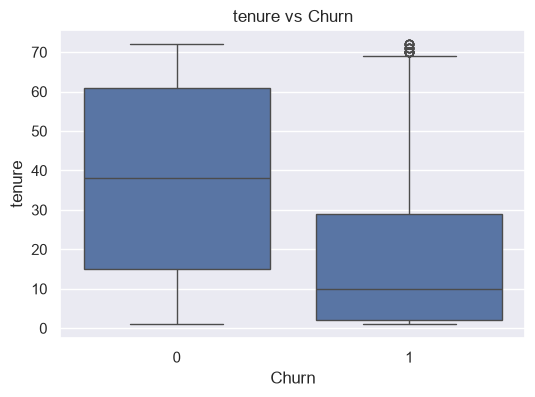

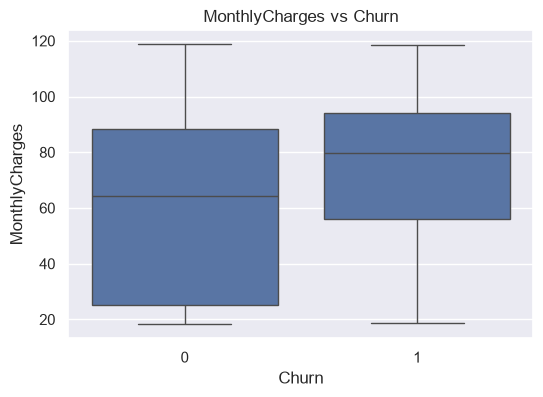

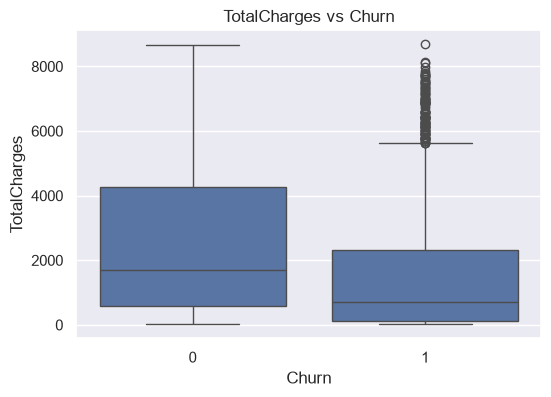


Variance Inflation Factor (VIF):
                                 feature           VIF
11                    InternetService_No  1.000800e+15
12    OnlineSecurity_No internet service  1.000800e+15
20       StreamingTV_No internet service  1.000800e+15
18       TechSupport_No internet service  1.000800e+15
16  DeviceProtection_No internet service  1.000800e+15
7                       PhoneService_Yes  1.000800e+15
8         MultipleLines_No phone service  1.000800e+15
14      OnlineBackup_No internet service  1.000800e+15
22   StreamingMovies_No internet service  1.000800e+15
2                         MonthlyCharges  8.660896e+02

Note: MonthlyCharges, TotalCharges, and tenure may exhibit strong dependency.
This can cause multicollinearity and should be considered when selecting variables.

Correlation matrix for numerical predictors:
                  tenure  MonthlyCharges  TotalCharges
tenure          1.000000        0.246862      0.825880
MonthlyCharges  0.246862        1.000000  

In [26]:
# Step 2: EDA for logistic regression assumptions
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 1) Target variable distribution: class imbalance
print('Churn distribution (proportion):')
print(df['Churn'].value_counts(normalize=True))

# 2) Continuous variables vs. churn
for col in ['tenure', 'MonthlyCharges', 'TotalCharges']:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x='Churn', y=col, data=df)
    plt.title(f'{col} vs Churn')
    plt.xlabel('Churn')
    plt.ylabel(col)
    plt.show()

# 3) Multicollinearity check via VIF
X_for_vif = pd.get_dummies(
    df.drop(columns=['Churn', 'customerID'], errors='ignore'),
    drop_first=True
).astype(float)

vif_df = pd.DataFrame({
    'feature': X_for_vif.columns,
    'VIF': [variance_inflation_factor(X_for_vif.values, i) for i in range(X_for_vif.shape[1])]
})

print('\nVariance Inflation Factor (VIF):')
print(vif_df.sort_values('VIF', ascending=False).head(10))

print('\nNote: MonthlyCharges, TotalCharges, and tenure may exhibit strong dependency.')
print('This can cause multicollinearity and should be considered when selecting variables.')

# Optional: inspect correlation among numeric variables
numeric_corr = df[['tenure', 'MonthlyCharges', 'TotalCharges']].corr()
print('\nCorrelation matrix for numerical predictors:')
print(numeric_corr)

### Step 3: Logistic regression modeling

We will fit a logistic regression model using both a statistical approach and a machine learning approach:
- `statsmodels` for coefficients, p-values, confidence intervals, and interpretability
- `sklearn` for train/test split, prediction, and evaluation metrics

We first create the design matrix with one-hot encoding for categorical features, dropping the first category to avoid perfect multicollinearity.

In [27]:
# Step 3: Build the logistic regression model
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Remove highly redundant features before modeling
model_df = df.drop(columns=['customerID'], errors='ignore')
if 'TotalCharges' in model_df.columns:
    model_df = model_df.drop(columns=['TotalCharges'])

# One-hot encoding with first category dropped
X = pd.get_dummies(
    model_df.drop(columns=['Churn']),
    drop_first=True,
    dtype=float
)

# Remove duplicate and constant columns that often trigger singular matrices
X = X.loc[:, ~X.columns.duplicated()]
X = X.loc[:, X.nunique() > 1]

# Drop near-perfectly collinear columns automatically
corr = X.corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
collinear_cols = [col for col in upper.columns if any(upper[col].fillna(0) > 0.999999)]
if collinear_cols:
    print('Dropping near-collinear columns before fitting:', collinear_cols)
    X = X.drop(columns=collinear_cols, errors='ignore')

y = df['Churn'].astype(int)

# Check design matrix rank before fitting
X_sm = sm.add_constant(X)
rank = np.linalg.matrix_rank(X_sm)
print('Design matrix shape:', X_sm.shape)
print('Matrix rank:', rank)
print('Full rank?', rank == X_sm.shape[1])

try:
    logit_model = sm.Logit(y, X_sm).fit(disp=False)
except np.linalg.LinAlgError:
    # Fallback for remaining singular cases: drop any remaining perfectly collinear columns
    corr2 = X_sm.corr().abs()
    upper2 = corr2.where(np.triu(np.ones(corr2.shape), k=1).astype(bool))
    extra_cols = [col for col in upper2.columns if any(upper2[col].fillna(0) > 0.999999)]
    if extra_cols:
        X_sm = X_sm.drop(columns=extra_cols, errors='ignore')
        print('Dropped remaining collinear columns:', extra_cols)
        logit_model = sm.Logit(y, X_sm).fit(disp=False)
    else:
        raise

print(logit_model.summary())

# sklearn train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Standardize features for logistic regression
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

clf = LogisticRegression(max_iter=1000)
clf.fit(X_train_s, y_train)

print('\nModel fitted successfully.')
print('Train shape:', X_train_s.shape)
print('Test shape:', X_test_s.shape)

Dropping near-collinear columns before fitting: ['MultipleLines_No phone service', 'OnlineSecurity_No internet service', 'OnlineBackup_No internet service', 'DeviceProtection_No internet service', 'TechSupport_No internet service', 'StreamingTV_No internet service', 'StreamingMovies_No internet service']
Design matrix shape: (7032, 23)
Matrix rank: 23
Full rank? True
                           Logit Regression Results                           
Dep. Variable:                  Churn   No. Observations:                 7032
Model:                          Logit   Df Residuals:                     7009
Method:                           MLE   Df Model:                           22
Date:                Mon, 31 Aug 2026   Pseudo R-squ.:                  0.2817
Time:                        13:43:59   Log-Likelihood:                -2924.5
converged:                       True   LL-Null:                       -4071.7
Covariance Type:            nonrobust   LLR p-value:                     0.00

### Step 4: Model evaluation

Because churn is usually an imbalanced outcome, we should not rely only on accuracy. The more informative metrics are:
- AUC (Area Under the ROC Curve)
- Precision, Recall, and F1-score for the churn class
- confusion matrix
- ROC curve

This is especially important because a model can appear to perform well in accuracy while missing many real churn customers.

Classification report:
              precision    recall  f1-score   support

           0     0.8514    0.8877    0.8692      1033
           1     0.6485    0.5722    0.6080       374

    accuracy                         0.8038      1407
   macro avg     0.7500    0.7299    0.7386      1407
weighted avg     0.7975    0.8038    0.7998      1407


AUC score:
0.8333044297539484

Confusion matrix:
[[917 116]
 [160 214]]


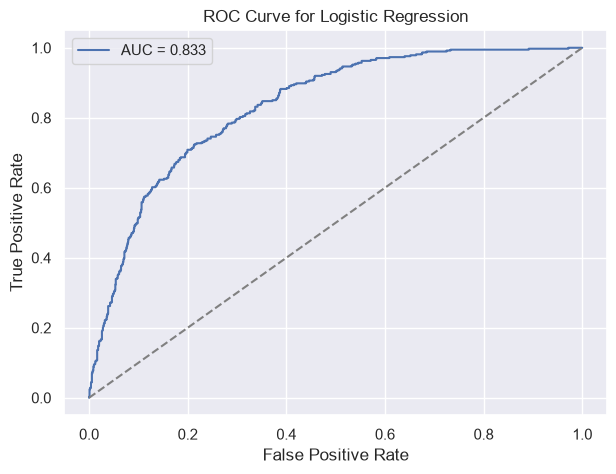

In [28]:
# Step 4: Evaluate the model
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    roc_curve,
    confusion_matrix
)

# Predictions and probabilities
y_pred = clf.predict(X_test_s)
y_prob = clf.predict_proba(X_test_s)[:, 1]

print('Classification report:')
print(classification_report(y_test, y_pred, digits=4))

print('\nAUC score:')
print(roc_auc_score(y_test, y_prob))

print('\nConfusion matrix:')
print(confusion_matrix(y_test, y_pred))

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc_score(y_test, y_prob):.3f}')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for Logistic Regression')
plt.legend()
plt.show()

### Step 5: Coefficient interpretation and odds ratios

From the `statsmodels` output, the coefficients can be converted to odds ratios to interpret the direction and magnitude of effect.

Interpretation rule:
- OR > 1 means the predictor increases the odds of churn.
- OR < 1 means the predictor decreases the odds of churn.
- OR = 1 means no effect.

This interpretation is valid only after controlling for the other variables in the model. It is not a causal claim, but it is a useful business insight.

In [29]:
# Step 5: Odds ratios and interpretation
odds_ratios = np.exp(logit_model.params)
conf_int = np.exp(logit_model.conf_int())
conf_table = pd.DataFrame({
    'OR': odds_ratios,
    'lower_95': conf_int.iloc[:, 0],
    'upper_95': conf_int.iloc[:, 1]
})

print('Odds ratios (sorted by effect size):')
print(conf_table.sort_values('OR', ascending=False).head(10))

print('\nExample interpretation:')
print("- If the OR for 'Contract_Two year' is below 1, it means customers with two-year contracts have lower churn odds than the reference group, after controlling for other variables.")
print("- If the OR for 'InternetService_Fiber optic' is above 1, it suggests higher churn risk for fiber users relative to the reference category.")
print("- If the OR for tenure is below 1, longer tenure generally reduces churn risk, holding other factors constant.")

Odds ratios (sorted by effect size):
                                      OR  lower_95   upper_95
InternetService_Fiber optic     5.561710  1.149810  26.902370
const                           1.840456  0.374418   9.046792
StreamingMovies_Yes             1.832468  0.961403   3.492746
StreamingTV_Yes                 1.810534  0.950680   3.448096
MultipleLines_Yes               1.590556  1.121608   2.255575
PaperlessBilling_Yes            1.399335  1.209725   1.618666
PaymentMethod_Electronic check  1.368374  1.136809   1.647109
SeniorCitizen                   1.243715  1.052998   1.468973
DeviceProtection_Yes            1.176895  0.831284   1.666196
PhoneService_Yes                1.173644  0.326282   4.221629

Example interpretation:
- If the OR for 'Contract_Two year' is below 1, it means customers with two-year contracts have lower churn odds than the reference group, after controlling for other variables.
- If the OR for 'InternetService_Fiber optic' is above 1, it suggests higher c